In [19]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import matplotlib
import keras
import matplotlib.pyplot as plt


In [20]:
from keras.models import Sequential
from keras.layers import Dense, Input
from keras import optimizers
from sklearn import model_selection
from keras import regularizers
from datetime import datetime

In [21]:
df = pd.read_csv("data/blood_cell_anomaly_detection.csv")
df

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,...,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,...,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,...,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,...,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,...,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,...,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5875,CELL_003773,Platelet,0,Normal_Platelet,2.30,0.0,0.000,1.000,0.699,0.536,...,81.4,34.2,CytoData,May_Grunwald_Giemsa,Olympus_BX51,40,360,0.1178,1.0000,0.8849
5876,CELL_005192,Target_Cell,1,Anemia,8.80,0.0,0.000,1.000,0.831,0.199,...,88.1,34.4,Raabin_WBC,Giemsa,Zeiss_Axio,40,224,0.9034,0.9475,0.5928
5877,CELL_005227,Target_Cell,1,Anemia,9.57,0.0,0.000,1.000,0.900,0.320,...,86.7,34.0,PBC_Dataset,Giemsa,Olympus_BX51,40,256,0.8493,0.6716,0.6381
5878,CELL_005391,Hypersegmented_Neutrophil,1,Infection,11.98,67.8,0.528,0.309,0.752,0.505,...,96.5,32.9,CytoData,Giemsa,Leica_DM2000,100,256,0.9004,0.6449,0.8801


In [22]:
print("Shape original:", df.shape)
print("\nDistribuição do target (anomaly_label):")
print(df['anomaly_label'].value_counts())
print(f"\nProporção: {df['anomaly_label'].value_counts(normalize=True).round(3).to_dict()}")

Shape original: (5880, 36)

Distribuição do target (anomaly_label):
anomaly_label
0    4000
1    1880
Name: count, dtype: int64

Proporção: {0: 0.68, 1: 0.32}


In [23]:
colunas_remover = [
    'cell_id',
    'cell_type',
    'disease_category',
    'cytodiffusion_anomaly_score',
    'cytodiffusion_classification_confidence',
    'labeller_confidence_score',
    'dataset_source',
    'staining_protocol',
    'microscope_model',
    'magnification_x',
    'image_resolution_px'
]
 
df = df.drop(columns=colunas_remover)
print("\nColunas após remoção:", df.shape[1])
print(df.columns.tolist())


Colunas após remoção: 25
['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']


In [24]:
nulos = df.isnull().sum()
print("\nValores nulos por coluna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "Nenhum valor nulo encontrado.")


Valores nulos por coluna:
Nenhum valor nulo encontrado.


In [25]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le_sex = LabelEncoder()
df['patient_sex'] = le_sex.fit_transform(df['patient_sex'])
print("\nEncoding patient_sex:", dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_))))

age_order = {'Pediatric': 0, 'Adult': 1, 'Elderly': 2}
df['patient_age_group'] = df['patient_age_group'].map(age_order)
print("Encoding patient_age_group:", age_order)


Encoding patient_sex: {'F': np.int64(0), 'M': np.int64(1)}
Encoding patient_age_group: {'Pediatric': 0, 'Adult': 1, 'Elderly': 2}


In [26]:
X = df.drop(columns=['anomaly_label'])
y = df['anomaly_label']
 
d = X.shape[1]
N = X.shape[0]
 
print(f"\nNúmero de amostras (N): {N}")
print(f"Número de features (d): {d}")
print(f"\nFeatures utilizadas:\n{X.columns.tolist()}")


Número de amostras (N): 5880
Número de features (d): 24

Features utilizadas:
['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"\nTamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste:  {X_test.shape[0]} amostras")
print(f"Tamanho do conjunto de validação:  {X_val.shape[0]} amostras")
print(f"\nDistribuição no treino:\n{y_train.value_counts()}")
print(f"\nDistribuição no teste:\n{y_test.value_counts()}")
print(f"\nDistribuição na validação:\n{y_val.value_counts()}")


Tamanho do conjunto de treino: 4116 amostras
Tamanho do conjunto de teste:  882 amostras
Tamanho do conjunto de validação:  882 amostras

Distribuição no treino:
anomaly_label
0    2800
1    1316
Name: count, dtype: int64

Distribuição no teste:
anomaly_label
0    600
1    282
Name: count, dtype: int64

Distribuição na validação:
anomaly_label
0    600
1    282
Name: count, dtype: int64


In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.copy())
X_test = scaler.transform(X_test.copy())
X_val = scaler.transform(X_val.copy())
 
# Convertendo de volta para DataFrame para facilitar visualização
X_train= pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test,  columns=X.columns)
X_val = pd.DataFrame(X_val,  columns=X.columns)

print("\nVerificação após padronização (treino) — primeiras 5 features:")
print(X_train.describe().T[['mean', 'std']].round(4).head(5))


Verificação após padronização (treino) — primeiras 5 features:
                   mean     std
cell_diameter_um   -0.0  1.0001
nucleus_area_pct   -0.0  1.0001
chromatin_density  -0.0  1.0001
cytoplasm_ratio     0.0  1.0001
circularity        -0.0  1.0001


In [29]:
CT = X_train.shape[0]
n_max = int((CT - 10) / (10 * (d + 2)))
 
print(f"\n--- Regra de Ouro (Teoria da Generalização) ---")
print(f"|CT| = {CT}, d = {d}")
print(f"n_max = floor(({CT} - 10) / (10 * ({d} + 2)))")
print(f"n_max = floor({CT - 10} / {10 * (d + 2)})")
print(f"n_max = {n_max} neurônios na camada escondida")


--- Regra de Ouro (Teoria da Generalização) ---
|CT| = 4116, d = 24
n_max = floor((4116 - 10) / (10 * (24 + 2)))
n_max = floor(4106 / 260)
n_max = 15 neurônios na camada escondida


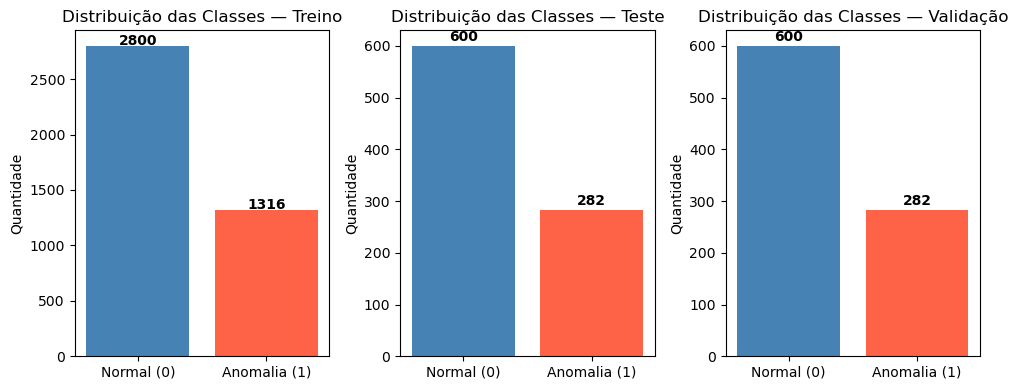


✅ Pré-processamento concluído!
   X_train_scaled: (4116, 24)
   X_test_scaled:  (882, 24)
   X_val_scaled:  (882, 24)


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
 
for ax, (data, title) in zip(axes, [
    (y_train, 'Treino'),
    (y_test,  'Teste'),
    (y_val, 'Validação')
]):
    counts = data.value_counts()
    ax.bar(['Normal (0)', 'Anomalia (1)'], counts.values,
           color=['steelblue', 'tomato'])
    ax.set_title(f'Distribuição das Classes — {title}')
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 10, str(v), ha='center', fontweight='bold')
 
plt.tight_layout()
plt.show()
 
print("\n✅ Pré-processamento concluído!")
print(f"   X_train_scaled: {X_train.shape}")
print(f"   X_test_scaled:  {X_test.shape}")
print(f"   X_val_scaled:  {X_val.shape}")

In [32]:
model = Sequential()

model.add(Input(shape=(24,)))

model.add(Dense(15, kernel_initializer='he_uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='glorot_uniform', activation='sigmoid'))

initial_weights = model.get_weights()

sgd = optimizers.SGD(learning_rate=0.01)

model.compile(loss='binary_crossentropy', optimizer=sgd, metrics=['accuracy', 'AUC'])

print(model.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 15)             │           375 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391 (1.53 KB)

 Trainable params: 391 (1.53 KB)

 Non-trainable params: 0 (0.00 B)

None


In [33]:
model.set_weights(initial_weights)

history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(X_val, y_val))

Epoch 1/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - AUC: 0.6292 - accuracy: 0.7036 - loss: 0.6130 - val_AUC: 0.7058 - val_accuracy: 0.7517 - val_loss: 0.5548
Epoch 2/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7582 - accuracy: 0.7957 - loss: 0.5131 - val_AUC: 0.7790 - val_accuracy: 0.7982 - val_loss: 0.4908
Epoch 3/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.7972 - accuracy: 0.8256 - loss: 0.4676 - val_AUC: 0.8116 - val_accuracy: 0.8141 - val_loss: 0.4569
Epoch 4/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8169 - accuracy: 0.8394 - loss: 0.4400 - val_AUC: 0.8330 - val_accuracy: 0.8186 - val_loss: 0.4330
Epoch 5/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8315 - accuracy: 0.8455 - loss: 0.4208 - val_AUC: 0.8445 - val_accuracy: 0.8265 - val_loss: 0.4168
Epoch 6/100
258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - AUC: 0.8417 - accuracy: 0.8508 - loss: 0.4060 - val_AUC: 0.8525 - val_accuracy: 0.8333 - val_loss: 0.4048
Epoch 7/100
258/258 ━━━━━━━━━━━━━━

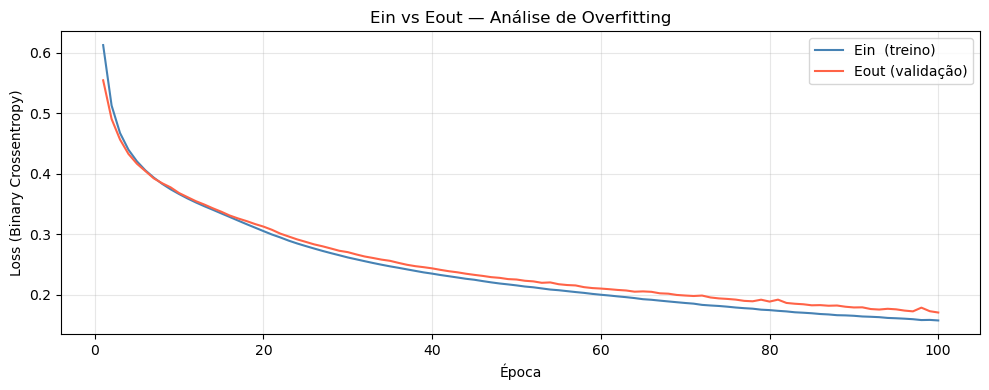


Menor Eout em: época 100
Ein  na época 100: 0.1577
Eout na época 100: 0.1708

Sem overfitting evidente nas 100 épocas


In [37]:
ein  = history.history['loss']
eout = history.history['val_loss']
epocas = range(1, len(ein) + 1)
 
plt.figure(figsize=(10, 4))
plt.plot(epocas, ein,  label='Ein  (treino)',    color='steelblue')
plt.plot(epocas, eout, label='Eout (validação)', color='tomato')
plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Ein vs Eout — Análise de Overfitting')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
# Identificar época de início do overfitting
melhor_epoca = int(np.argmin(eout)) + 1
print(f"\nMenor Eout em: época {melhor_epoca}")
print(f"Ein  na época {melhor_epoca}: {ein[melhor_epoca-1]:.4f}")
print(f"Eout na época {melhor_epoca}: {eout[melhor_epoca-1]:.4f}")
 
if eout[-1] > eout[melhor_epoca-1]:
    print(f"\nOverfitting detectado a partir da época {melhor_epoca}")
else:
    print(f"\nSem overfitting evidente nas {len(ein)} épocas")

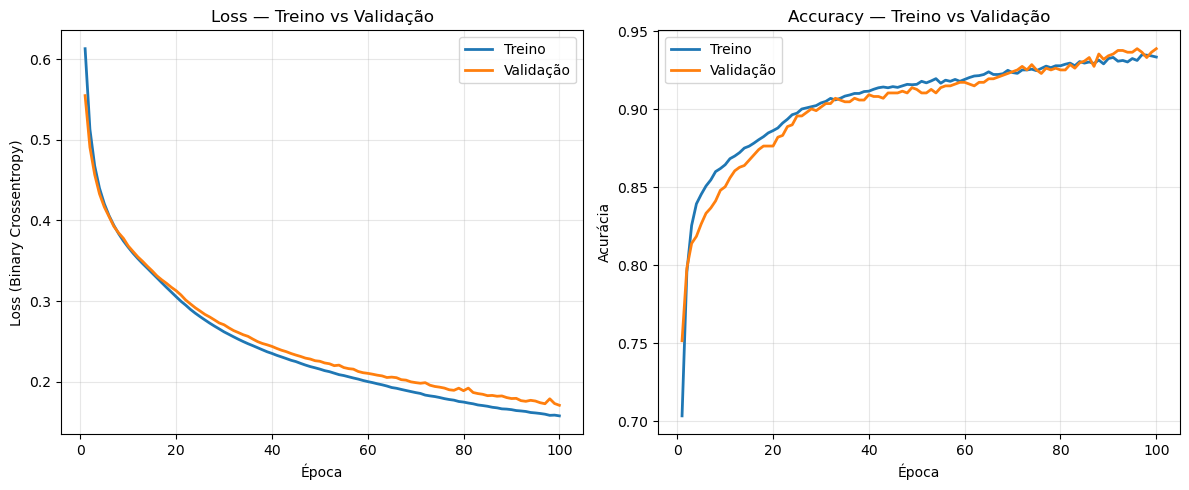


Menor val_loss em: época 100
Loss treino: 0.1577
Loss validação: 0.1708

Sem overfitting evidente


In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Loss
ein  = history.history['loss']
eout = history.history.get('val_loss')  # evita erro

epocas = range(1, len(ein) + 1)

plt.figure(figsize=(12, 5))

# --- LOSS ---
plt.subplot(1, 2, 1)
plt.plot(epocas, ein, label='Treino', linewidth=2)
if eout is not None:
    plt.plot(epocas, eout, label='Validação', linewidth=2)

plt.xlabel('Época')
plt.ylabel('Loss (Binary Crossentropy)')
plt.title('Loss — Treino vs Validação')
plt.legend()
plt.grid(alpha=0.3)

# --- ACCURACY ---
acc  = history.history.get('accuracy')
val_acc = history.history.get('val_accuracy')

plt.subplot(1, 2, 2)
if acc is not None:
    plt.plot(epocas, acc, label='Treino', linewidth=2)
if val_acc is not None:
    plt.plot(epocas, val_acc, label='Validação', linewidth=2)

plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Accuracy — Treino vs Validação')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# -----------------------------
# DETECÇÃO DE OVERFITTING
# -----------------------------
if eout is not None:
    melhor_epoca = int(np.argmin(eout)) + 1

    print(f"\nMenor val_loss em: época {melhor_epoca}")
    print(f"Loss treino: {ein[melhor_epoca-1]:.4f}")
    print(f"Loss validação: {eout[melhor_epoca-1]:.4f}")

    if eout[-1] > eout[melhor_epoca-1]:
        print(f"\nOverfitting detectado a partir da época {melhor_epoca}")
    else:
        print(f"\nSem overfitting evidente")

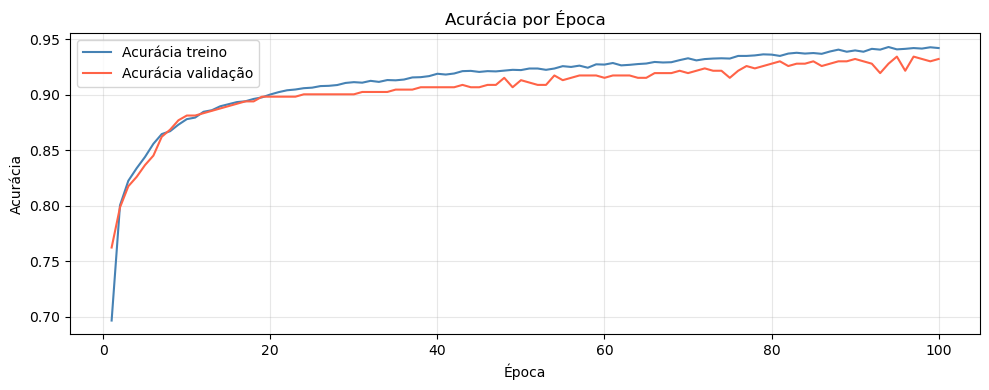

In [18]:
acc_train = history.history['accuracy']
acc_val   = history.history['val_accuracy']
 
plt.figure(figsize=(10, 4))
plt.plot(epocas, acc_train, label='Acurácia treino',    color='steelblue')
plt.plot(epocas, acc_val,   label='Acurácia validação', color='tomato')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.title('Acurácia por Época')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()